In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [27]:
df = pd.read_csv("Medicaldataset.csv")
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [28]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [29]:
df.to_csv("medical_dataset_export.csv", index=False)

In [31]:
df.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [6]:
df['Result'].value_counts()

Result
positive    810
negative    509
Name: count, dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.drop_duplicates(inplace=True)

In [36]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Result'] = le.fit_transform(df['Result'])

In [37]:
X = df.drop('Result', axis=1)
y = df['Result']

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [40]:
df.describe()
df.mean()
df.std()

Age                         13.647315
Gender                       0.474027
Heart rate                  51.630270
Systolic blood pressure     26.122720
Diastolic blood pressure    14.033924
Blood sugar                 74.923045
CK-MB                       46.327083
Troponin                     1.154568
Result                       0.486991
dtype: float64

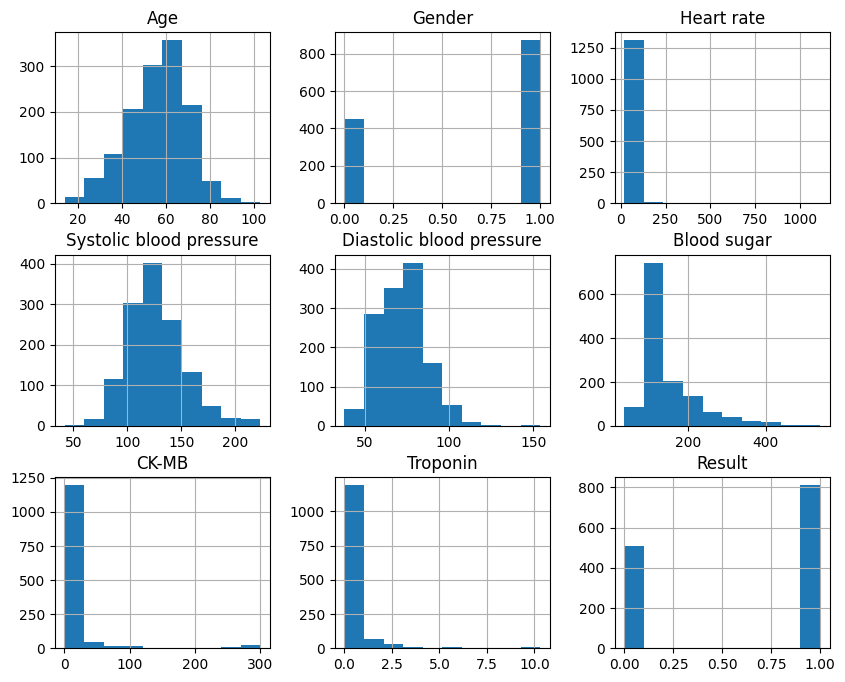

In [41]:
df.hist(figsize=(10,8))
plt.show()

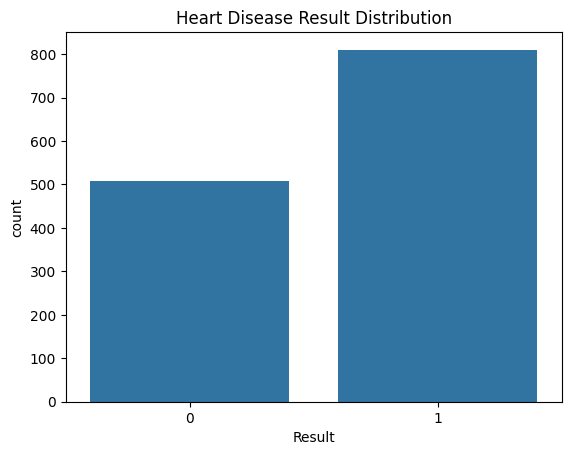

In [42]:
sns.countplot(x='Result', data=df)
plt.title("Heart Disease Result Distribution")
plt.show()

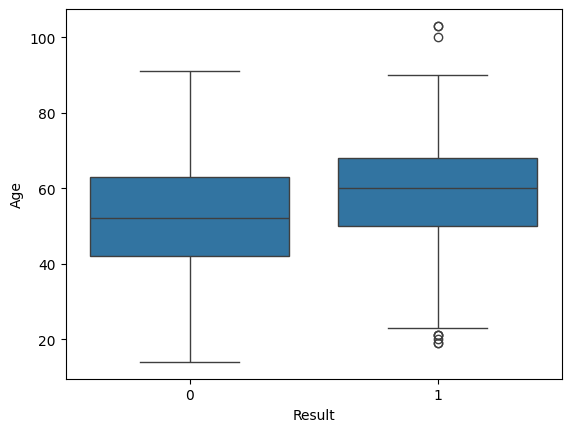

In [43]:
sns.boxplot(x='Result', y='Age', data=df)
plt.show()

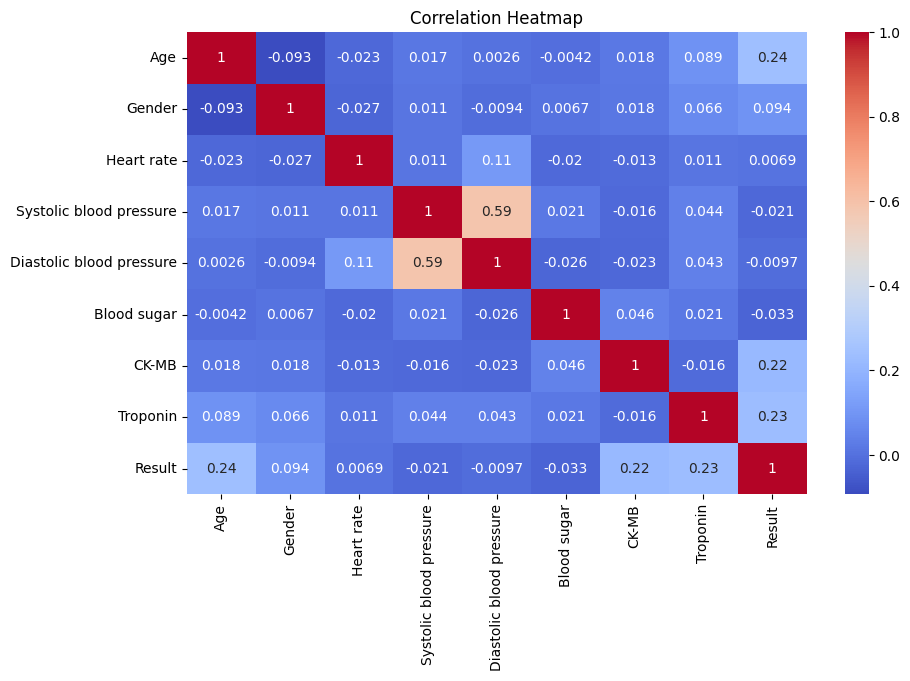

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

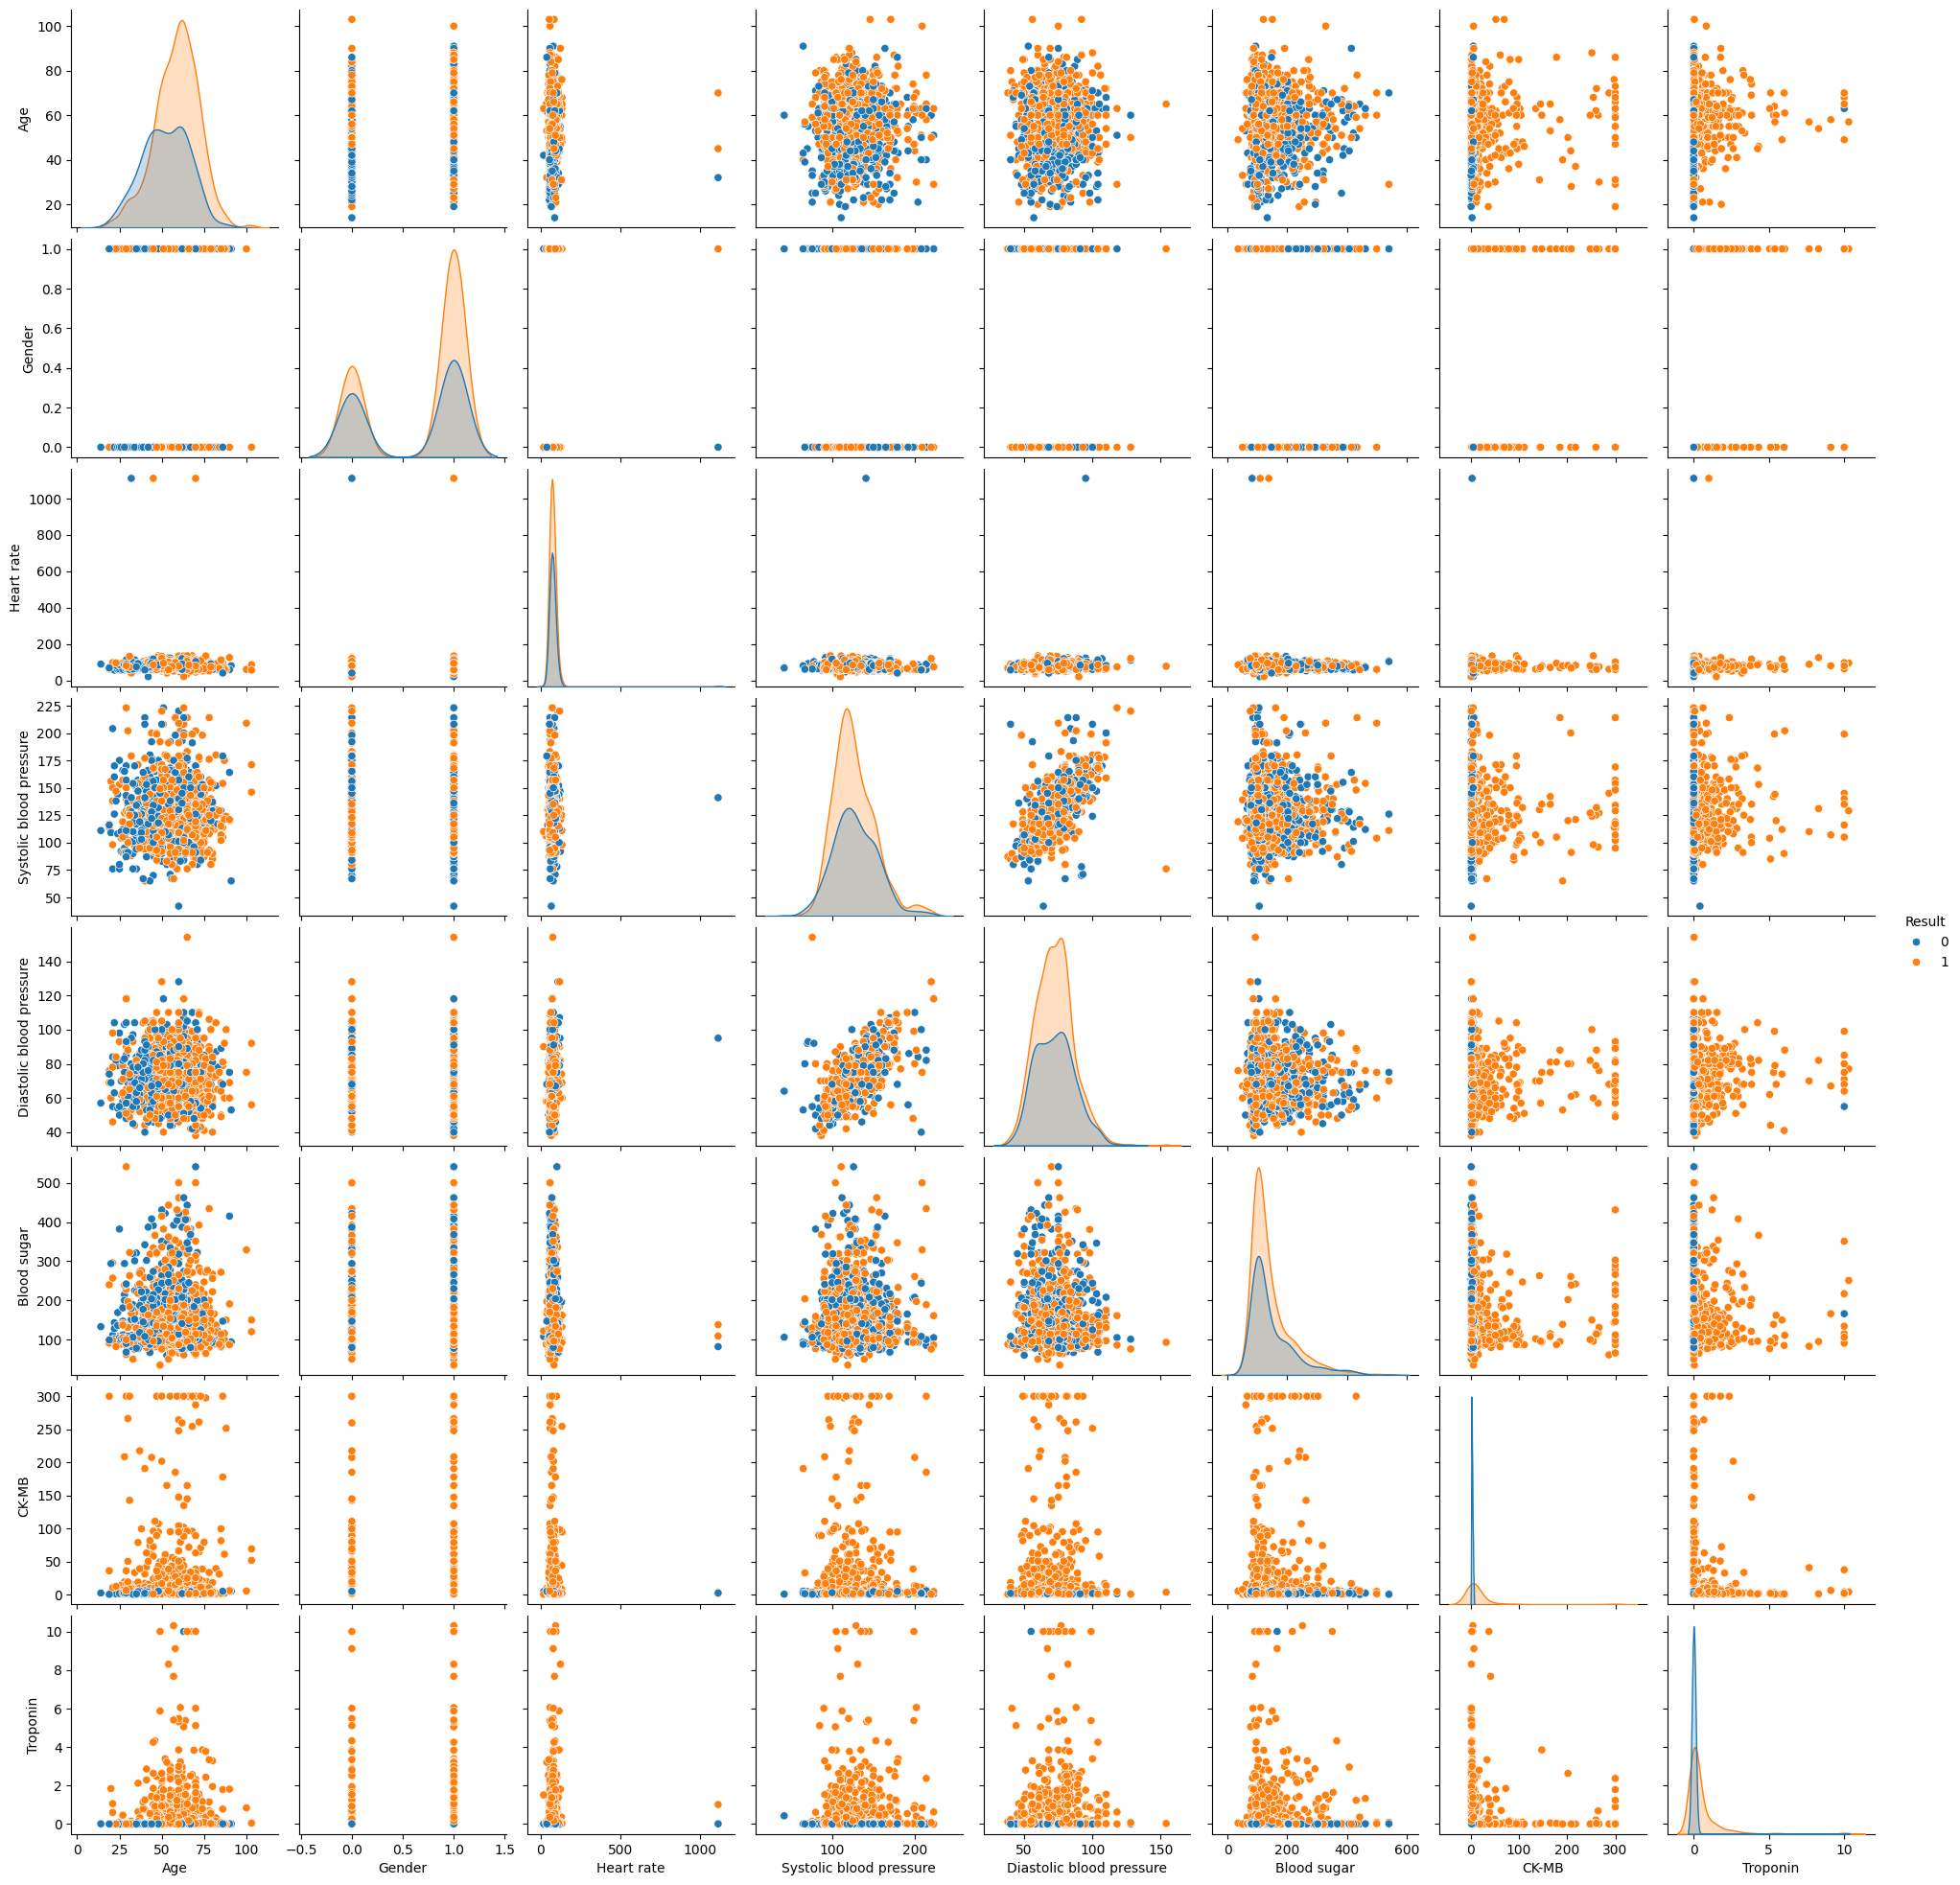

In [45]:
sns.pairplot(df, hue="Result")
plt.show()

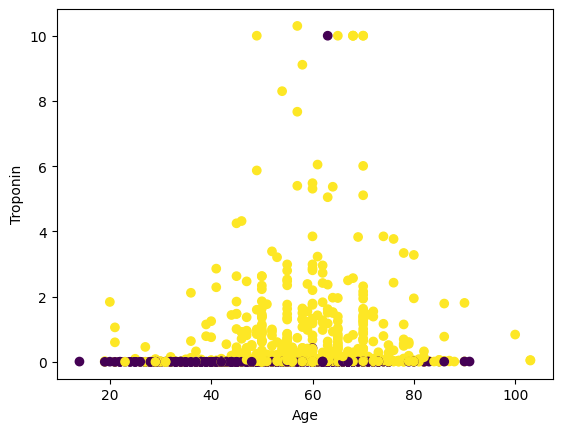

In [47]:
plt.scatter(df['Age'], df['Troponin'], c=df['Result'])
plt.xlabel("Age")
plt.ylabel("Troponin")
plt.show()

In [55]:
df['Result'].value_counts(normalize=True)

Result
1    0.614102
0    0.385898
Name: proportion, dtype: float64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [51]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [52]:
y_pred = knn.predict(X_test)

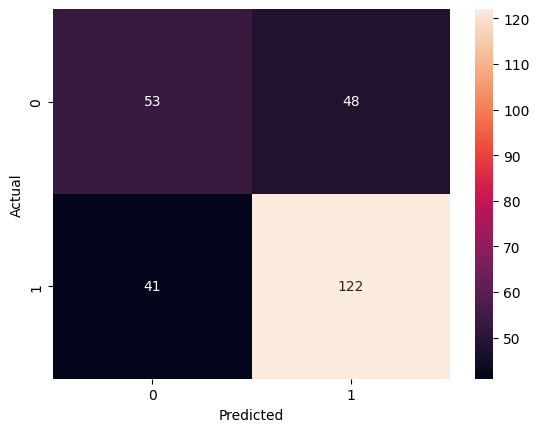

In [53]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.52      0.54       101
           1       0.72      0.75      0.73       163

    accuracy                           0.66       264
   macro avg       0.64      0.64      0.64       264
weighted avg       0.66      0.66      0.66       264

